#  Bank Marketing - Data Preprocessing

**DATA 4950 Week 6 Demo**

## What we will Cover
1. Load data
2. Simple cleaning (duplicates, obvious errors)
3. Remove data leakage feature
4. Train-test split (stratified)
5. Handle "unknown" values 
6. Handle outliers 
7. Build baseline regression model
8. Save for next notebook
   
### ⚠️ Key Rule: Split FIRST, then preprocess!
Any step that uses statistics (mean, median, IQR) must be fit on **training data only**.

In [1]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## settings for plots
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns',None)

## 1. Load Data

In [2]:
## load data
df = pd.read_csv('../data/raw/bank_marketing.csv')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## 2. Data Quality Assessment

In [4]:
## quick check

print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'\nTarget distribution:')
print(df['y'].value_counts())

Missing values: 0
Duplicate rows: 12

Target distribution:
y
no     36548
yes     4640
Name: count, dtype: int64


## 3. Data Preprocessing

### step 1. Handle Missing TARGET Values (Before Split!)

### Step 2: Simple Cleaning (Before Split - OK)

These operations are safe before splitting because they don't use statistics:
- Remove duplicates
- Drop data leakage features

In [5]:
## remove duplicates
duplicates = df.duplicated().sum()
print(f'\n Duplicate rows found: {duplicates}')


 Duplicate rows found: 12


In [6]:
if duplicates>0:
    df_clean = df.drop_duplicates()
    print(f'removed {duplicates} duplicated rows')
else:
    print('No duplicates removed')

removed 12 duplicated rows


In [7]:
## TODO: drop duration (data leakage!)

df_clean = df_clean.drop('duration', axis=1)
print(f'Drop duration column')
print(f'Remaining columns: {df_clean.shape[1]}')


Drop duration column
Remaining columns: 20


In [8]:
# encode target variable: yes=1, no=0

df_clean['y'] = (df_clean['y']=='yes').astype('int')

print('Target encoded:')
print(df_clean['y'].value_counts())

Target encoded:
y
0    36537
1     4639
Name: count, dtype: int64


In [9]:
# check current columns

print(f'Shape: {df_clean.shape}')
print(f'\nNumerical: {df_clean.select_dtypes(include=["int64","float64"]).columns.tolist()}')
print(f'\nCategorical: {df_clean.select_dtypes(include="object").columns.tolist()}')

Shape: (41176, 20)

Numerical: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### Step 3. Train-Test Split

**Now we split.** After this point, all operations using statistics must:
1. Be **fit on training data only**
2. Be **applied to both** train and test sets

In [10]:
## seperate features and target
X = df_clean.drop('y',axis=1)
y = df_clean['y']

In [11]:
X

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6


In [12]:
y

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: y, Length: 41176, dtype: int64

In [13]:
print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")


Features (X) shape: (41176, 19)
Target (y) shape: (41176,)


In [14]:
## TODO: split first!
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=4950,
     stratify=y ## keeps same class ratio in both sets
)

In [15]:
print(f'Training:{X_train.shape[0]:,} samples')
print(f'Ttest:{X_test.shape[0]:,} samples')

Training:32,940 samples
Ttest:8,236 samples


In [16]:
X_train

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
17509,48,technician,married,professional.course,no,yes,no,cellular,jul,mon,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
35492,45,blue-collar,single,high.school,unknown,yes,no,cellular,may,mon,6,999,1,failure,-1.8,92.893,-46.2,1.244,5099.1
37144,40,admin.,married,university.degree,no,no,no,cellular,aug,wed,2,999,1,failure,-2.9,92.201,-31.4,0.884,5076.2
14307,47,retired,single,basic.6y,unknown,no,no,cellular,jul,mon,5,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
9183,56,blue-collar,married,high.school,unknown,yes,no,telephone,jun,fri,3,999,0,nonexistent,1.4,94.465,-41.8,4.967,5228.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27645,45,technician,single,university.degree,no,no,no,cellular,nov,fri,2,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8
2915,51,technician,married,professional.course,no,no,no,telephone,may,wed,2,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0
6588,40,admin.,single,high.school,no,yes,no,telephone,may,wed,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
24000,56,unknown,married,unknown,no,no,no,telephone,oct,fri,1,999,0,nonexistent,-0.1,93.798,-40.4,5.045,5195.8


In [17]:
X_test

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
23179,59,housemaid,married,unknown,unknown,yes,no,cellular,aug,tue,2,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1
21488,48,management,married,university.degree,no,no,no,cellular,aug,tue,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1
38708,28,admin.,married,high.school,no,no,no,cellular,nov,tue,2,999,0,nonexistent,-3.4,92.649,-30.1,0.715,5017.5
16369,26,services,single,high.school,no,yes,no,cellular,jul,wed,10,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1
8500,50,admin.,married,university.degree,no,yes,no,telephone,jun,wed,1,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15412,32,admin.,single,university.degree,no,yes,no,cellular,jul,fri,1,999,0,nonexistent,1.4,93.918,-42.7,4.957,5228.1
33402,59,housemaid,divorced,basic.6y,unknown,yes,no,cellular,may,tue,1,999,0,nonexistent,-1.8,92.893,-46.2,1.291,5099.1
32700,35,technician,married,university.degree,no,yes,no,cellular,may,mon,3,999,0,nonexistent,-1.8,92.893,-46.2,1.299,5099.1
27595,49,unemployed,single,high.school,no,yes,no,telephone,nov,fri,2,999,1,failure,-0.1,93.200,-42.0,4.021,5195.8


In [18]:
print('y_train ratio', y_train.value_counts(normalize=True) * 100)
print('y_test ratio', y_test.value_counts(normalize=True) * 100)

y_train ratio y
0    88.734062
1    11.265938
Name: proportion, dtype: float64
y_test ratio y
0    88.732394
1    11.267606
Name: proportion, dtype: float64


### Step 4. Handle "unknown" FEATURE Values

This dataset uses "unknown" instead of NaN. Strategy based on percentage:

**Columns with LOW unknowns (under 5%) - Impute with mode:**
- job: ~0.8% unknown
- marital: ~0.2% unknown
- education: ~4.2% unknown
- housing: ~2.4% unknown
- loan: ~2.4% unknown

**Columns with HIGH unknowns (over 15%) - Keep as category:**
- default: ~20.9% unknown → Keep it! User refused to disclose may be a signal.

In [19]:
## check unknowns in training data

cols_with_unknown = []

for col in df_clean.select_dtypes(include='object').columns:
    unknown_count = (df_clean[col]=='unknown').sum()
    if unknown_count >0:
        pct = unknown_count/len(df_clean)*100
        print(f'{col}: {unknown_count} unknowns ({pct:.1f}%)')

        cols_with_unknown.append(col)

job: 330 unknowns (0.8%)
marital: 80 unknowns (0.2%)
education: 1730 unknowns (4.2%)
default: 8596 unknowns (20.9%)
housing: 990 unknowns (2.4%)
loan: 990 unknowns (2.4%)


In [20]:
cols_with_unknown

['job', 'marital', 'education', 'default', 'housing', 'loan']

#### Method 1: Drop rows with missing ("unknown") values (Simple but loses data)

In [21]:
## drop rows only if a specific column is missing
X_train_dropped_specific = X_train[(X_train['job']!='unknown')]
print(f'X_train Original rows: {len(X_train)}')
print(f'X_train After dropping  job samples: {len(X_train_dropped_specific)}')

X_train Original rows: 32940
X_train After dropping  job samples: 32689


In [22]:
## drop ALL rows with any missing value
X_train_dropped = X_train[~(X_train[cols_with_unknown]=='unknown').any(axis=1)]
print(f'X_train Original rows: {len(X_train)}')
print(f'        After dropping ALL unknowns: {len(X_train_dropped)}')
print(f'        Rows lost: {len(X_train) - len(X_train_dropped)}')

X_train Original rows: 32940
        After dropping ALL unknowns: 24372
        Rows lost: 8568


#### Method 2: Fill with mode

In [23]:
# calculate mode from training data (excluding "unknown")
mode_loan = X_train[X_train['loan']!='unknown']['loan'].mode()[0]
print(f'Mode of loan: {mode_loan}')

Mode of loan: no


In [24]:
X_train['loan'].value_counts()

loan
no         27170
yes         4973
unknown      797
Name: count, dtype: int64

In [25]:
## fill missing values with training mode
X_train_fillmode_specific = X_train.copy()

# count unknowns before replacement
X_train_fillmode_specific['loan'] = X_train_fillmode_specific['loan'].replace('unknown',mode_loan)
print(f"X_train loan replaced {(X_train['loan']=='unknown').sum()} unknowns with '{mode_loan}' ")

X_test_fillmode_specific = X_test.copy()
X_test_fillmode_specific['loan'] = X_test_fillmode_specific['loan'].replace('unknown',mode_loan)
print(f"X_test loan replaced {(X_test['loan']=='unknown').sum()} unknowns with '{mode_loan}' ")

X_train loan replaced 797 unknowns with 'no' 
X_test loan replaced 193 unknowns with 'no' 


In [26]:
X_train_fillmode_specific['loan'].value_counts()

loan
no     27967
yes     4973
Name: count, dtype: int64

In [27]:
(X_train_fillmode_specific['loan']=='unknown').sum()

0

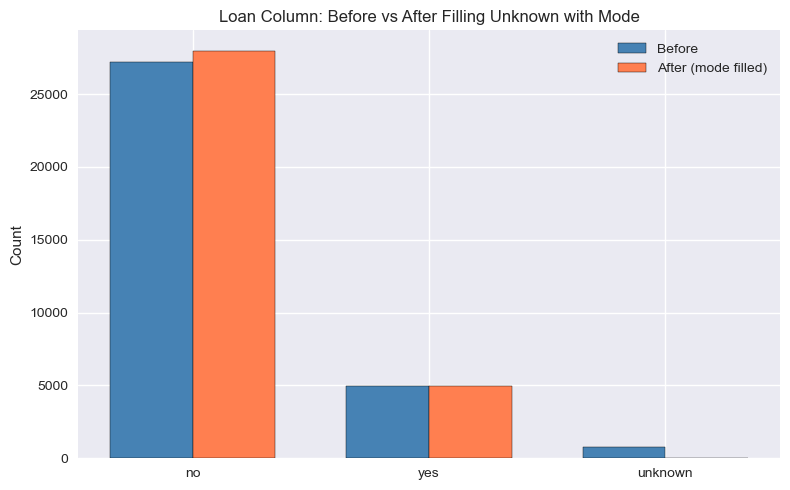

In [28]:
categories = ['no', 'yes', 'unknown']
before = X_train['loan'].value_counts().reindex(categories, fill_value=0)
after = X_train_fillmode_specific['loan'].value_counts().reindex(categories, fill_value=0)

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, before, width, label='Before', color='steelblue', edgecolor='black')
plt.bar(x + width/2, after, width, label='After (mode filled)', color='coral', edgecolor='black')
plt.xticks(x, categories)
plt.ylabel('Count')
plt.title('Loan Column: Before vs After Filling Unknown with Mode')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
cols_with_unknown

['job', 'marital', 'education', 'default', 'housing', 'loan']

In [30]:
## TODO: columns to impute (low % unknown)
## default is NOT in this list - we keep it as a category
impute_cols_with_unknown = ['job', 'marital', 'education',  'housing', 'loan']


In [31]:
X_train_fillmode = X_train.copy()
X_test_fillmode = X_test.copy()


for col in impute_cols_with_unknown:
    mode_value = X_train[X_train[col]!='unknown'][col].mode()[0]
    
    # count unknowns before replacement
    X_train_fillmode[col] = X_train_fillmode[col].replace('unknown',mode_value)
    X_test_fillmode[col] = X_test_fillmode[col].replace('unknown',mode_value)


In [32]:
## verify no unknowns remain

remaining = 0
for col in impute_cols_with_unknown:
    remaining = remaining + (X_train_fillmode[col] == 'unknown').sum()

print(f'Remaining unknowns in training: {remaining}')

Remaining unknowns in training: 0


### Step 5. Handle Outliers

### Outlier Handling Decisions (Domain-Aware)

| Column | Type | Outliers | Decision | Reasoning |
|--------|------|----------|----------|----------|
| `age` | Client | ~1.2% | **KEEP** | Elderly clients are real, not errors |
| `campaign` | Campaign | ~5.9% | **CAP** | 56 contacts is excessive, likely aggressive follow-up |
| `pdays` | Campaign | ~3.7% | **KEEP** | 999 = "never contacted" (sentinel value, not outlier!) |
| `previous` | Campaign | ~13.8% | **KEEP** | High counts are real — some clients contacted many times |
| `cons.conf.idx` | **Macro** | ~1.1% | **DO NOT CAP** ❌ | Real economic data! |
| `emp.var.rate` | **Macro** | 0% | N/A | No outliers detected |
| `cons.price.idx` | **Macro** | 0% | N/A | No outliers detected |
| `euribor3m` | **Macro** | 0% | N/A | No outliers detected |
| `nr.employed` | **Macro** | 0% | N/A | No outliers detected |

In [33]:
X_train_clean = X_train_fillmode.copy()
X_test_clean = X_test_fillmode.copy()

In [34]:
## identify numerical columns

numerical_cols = X_train_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numerical columns ({len(numerical_cols)}):')
numerical_cols

Numerical columns (9):


['age',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [35]:
## compute outlier percentage for each numerical feature

for col in numerical_cols:
    Q1 = X_train_clean[col].quantile(0.25)
    Q3 = X_train_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    n_outliers = ((X_train_clean[col]<lower_bound)|(X_train_clean[col]>upper_bound)).sum()
    percent = (n_outliers/len(X_train_clean)) *100
    print(f'{col}: {n_outliers} outliers ({percent:.2f}%)')


age: 381 outliers (1.16%)
campaign: 1940 outliers (5.89%)
pdays: 1223 outliers (3.71%)
previous: 4560 outliers (13.84%)
emp.var.rate: 0 outliers (0.00%)
cons.price.idx: 0 outliers (0.00%)
cons.conf.idx: 357 outliers (1.08%)
euribor3m: 0 outliers (0.00%)
nr.employed: 0 outliers (0.00%)


#### Method 2: Cap outliers (Winsorization)

In [36]:
# TODO: cap outliers - ONLY campaign
columns_to_cap = ['campaign']

def cap_outlier(train_data, test_data, columns):
    train_capped = train_data.copy()
    test_capped = test_data.copy() 
    for col in columns:
        Q1 = train_capped[col].quantile(0.25)
        Q3 = train_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR

        train_capped[col] = train_capped[col].clip(lower=lower_bound,upper=upper_bound)
        test_capped[col] = test_capped[col].clip(lower=lower_bound,upper=upper_bound)
        
    return train_capped, test_capped


columns_to_cap = ['campaign']

X_train_final,X_test_final=  cap_outlier(X_train_clean,X_test_clean,columns_to_cap)


print(f'shape of X_train {X_train_final.shape:}')
print(f'shape of X_test {X_test_final.shape:}')



shape of X_train (32940, 19)
shape of X_test (8236, 19)


In [37]:
y_train.value_counts()

y
0    29229
1     3711
Name: count, dtype: int64

## 4. Data Validation

In [38]:
## 1. Check for missing values
print("\n1. Missing Values:")
print(f"   X_train: {X_train_final.isnull().sum().sum()} missing")
print(f"   X_test:  {X_test_final.isnull().sum().sum()} missing")
print(f"   y_train: {y_train.isnull().sum()} missing")
print(f"   y_test:  {y_test.isnull().sum()} missing")

## 2. Check for infinite values (numeric columns only)
print("\n2. Infinite Values:")
num_cols = X_train_final.select_dtypes(include=['int64', 'float64']).columns
print(f"   X_train: {np.isinf(X_train_final[num_cols]).sum().sum()} infinite")
print(f"   X_test:  {np.isinf(X_test_final[num_cols]).sum().sum()} infinite")

## 3. Check stratification (classification-specific)
print("\n3. Stratification Check:")
print(f"   y_train positive rate:  {(y_train == 1).mean():.4f} ({(y_train == 1).mean()*100:.1f}%)")
print(f"   y_test positive rate:  {(y_test == 1).mean():.4f} ({(y_test == 1).mean()*100:.1f}%)")

## 4. Final shapes
print("\n4. Final Shapes:")
print(f"   X_train: {X_train_final.shape}")
print(f"   X_test:  {X_test_final.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")


1. Missing Values:
   X_train: 0 missing
   X_test:  0 missing
   y_train: 0 missing
   y_test:  0 missing

2. Infinite Values:
   X_train: 0 infinite
   X_test:  0 infinite

3. Stratification Check:
   y_train positive rate:  0.1127 (11.3%)
   y_test positive rate:  0.1127 (11.3%)

4. Final Shapes:
   X_train: (32940, 19)
   X_test:  (8236, 19)
   y_train: (32940,)
   y_test:  (8236,)


In [39]:
import os
import pickle

# Create directory
os.makedirs('../data/processed', exist_ok=True)

# Save processed data
X_train_final.to_csv('../data/processed/X_train.csv', index=False)
X_test_final.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)


### Key Decisions Summary

Started with 41,188 samples

**Before Split (safe operations):** 
- reomved 12 duplicates - no statistics needed
- dropped "duration" - data leakage

**After Split (fit on training only):**
- Imputed the unknown using mode (most common values) for low-percentage columns (job, marital, education, loan and housing)
- Kept the unknowns as category for "default"
- Capped "campaign" outliers only
- Did not cap: age, pdays, previous, economic data


READY FOR MODELING:
  → 32,940 records for training (80%)
  → 8,236 records for testing (20%)
  → Same 11% "yes" rate in both sets (fair test)
